# Task 10 — Building a Question Answering (Q&A) System with T5

**Requirement source:** `Task 10.pdf`  **Data:** SQuAD_tiny (built exactly as in `Prepare_SQuAD_tiny.ipynb`)  **Hardware:** local NVIDIA GPU (CUDA) via Jupyter

| Subset | Size | Source indices |
|---|---|---|
| Train | 1,000 | SQuAD *train* 10,000–10,999 |
| Validation | 100 | SQuAD *validation* 3,000–3,099 |
| Test | 100 | SQuAD *validation* 3,100–3,199 |

| PDF item | Notebook section |
|---|---|
| 1. Preprocessing + why | §1 |
| 2A. Fine-tuning procedure & hyperparameters | §2A |
| 2B. Training & validation losses | §2B |
| 2C. Overfitting prevention | §2C |
| 3A/3B. ROUGE on test set + interpretation | §3 |
| 4A/4B. First 5 test samples, with / without context + comparison | §4 |
| 5A–5D. `mrm8488/t5-base-finetuned-squadv2` comparison (+ zero-shot baseline) | §5, §6 |

## 0. Setup — imports, GPU check, reproducibility

In [1]:
%matplotlib inline
import os, re, string, time, json
from collections import Counter
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import transformers
from datasets import load_dataset, load_from_disk
from transformers import (AutoTokenizer, AutoModelForSeq2SeqLM, T5ForConditionalGeneration,
                          Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq,
                          EarlyStoppingCallback, set_seed)
from transformers import logging as transformers_logging
from rouge_score import rouge_scorer
from tqdm.auto import tqdm
from IPython.display import display

os.environ["TOKENIZERS_PARALLELISM"] = "false"
transformers_logging.set_verbosity_error()
pd.set_option("display.max_colwidth", 120)

SEED = 42
set_seed(SEED)                     # python, numpy, torch (CPU + CUDA)

assert torch.cuda.is_available(), "CUDA GPU not visible to this kernel - check the PyTorch CUDA build."
device = torch.device("cuda")
USE_BF16 = torch.cuda.is_bf16_supported()   # bf16 is numerically safe for T5 (fp16 is known to overflow in T5)

print("PyTorch      :", torch.__version__, "| CUDA", torch.version.cuda)
print("Transformers :", transformers.__version__)
print("GPU          :", torch.cuda.get_device_name(0))
print("VRAM         : %.1f GB" % (torch.cuda.get_device_properties(0).total_memory / 1024**3))
print("bf16 support :", USE_BF16)

PyTorch      : 2.11.0+cu128 | CUDA 12.8
Transformers : 5.17.0
GPU          : NVIDIA GeForce RTX 5070 Laptop GPU
VRAM         : 8.0 GB
bf16 support : True


## 0.1 Create SQuAD_tiny
Same slicing as the provided `Prepare_SQuAD_tiny` notebook. The subsets are cached in `./SQuAD_tiny/` so the notebook is reproducible offline after the first run.

In [2]:
DATA_DIR = "SQuAD_tiny"
if all(os.path.isdir(f"{DATA_DIR}/{s}") for s in ["train", "validation", "test"]):
    train_dataset = load_from_disk(f"{DATA_DIR}/train")
    val_dataset   = load_from_disk(f"{DATA_DIR}/validation")
    test_dataset  = load_from_disk(f"{DATA_DIR}/test")
    print("Loaded SQuAD_tiny from disk")
else:
    squad = load_dataset("squad")
    train_dataset = squad["train"].select(range(10000, 11000))
    val_dataset   = squad["validation"].select(range(3000, 3100))
    test_dataset  = squad["validation"].select(range(3100, 3200))   # SQuAD has no public test split
    train_dataset.save_to_disk(f"{DATA_DIR}/train")
    val_dataset.save_to_disk(f"{DATA_DIR}/validation")
    test_dataset.save_to_disk(f"{DATA_DIR}/test")
    print("Downloaded SQuAD and saved SQuAD_tiny")

print("Size of training set  :", len(train_dataset))
print("Size of validation set:", len(val_dataset))
print("Size of testing set   :", len(test_dataset))
print("\nOverlapping contexts train/test:", len(set(train_dataset["context"]) & set(test_dataset["context"])))
display(pd.DataFrame(train_dataset[:3])[["title", "question", "answers"]])

Loaded SQuAD_tiny from disk
Size of training set  : 1000
Size of validation set: 100
Size of testing set   : 100

Overlapping contexts train/test: 0


,title,question,answers
0,Institute_of_technology,"When Konya Technical University opens, how many total institutes of technology will there be in Turkey and the Ottom...","{'text': ['six'], 'answer_start': [520]}"
1,Institute_of_technology,What two cities in Turkey acquired institutes of technology in the 1950s?,"{'text': ['Ankara and Trabzon'], 'answer_start': [248]}"
2,Institute_of_technology,What year did UK polytechnics start functioning in a binary education system?,"{'text': ['1970'], 'answer_start': [105]}"


## 1. Preprocessing for the T5 Q&A system

| # | Step | What is done | Why it is necessary |
|---|---|---|---|
| 1 | **Field extraction** | From each SQuAD record keep `question`, `context` and the first gold answer `answers["text"][0]`. | SQuAD stores answers as a list (plus character offsets for extractive models). A generative seq2seq model needs exactly one target string per input. |
| 2 | **Text-to-text formatting** | Input string = `question: <question>  context: <context>`. | T5 casts every task as text→text and relies on a task prefix to know what to do. This is also the exact format used by `mrm8488/t5-base-finetuned-squadv2`, so both models in §5 see identical inputs. |
| 3 | **SentencePiece tokenisation** | `t5-small` tokenizer converts text to sub-word IDs and appends `</s>`. | The model only consumes IDs from its 32k vocabulary; sub-words mean no out-of-vocabulary tokens for rare names/numbers common in SQuAD. |
| 4 | **Truncation** | Inputs truncated to `MAX_INPUT_LENGTH = 512`; answers to `MAX_TARGET_LENGTH = 64`. | Bounds memory/compute (attention is O(n²)); 512 is T5's pre-training length. The check below shows how many examples actually hit the limit and whether the answer survives. |
| 5 | **Target labels** | Tokenised answer IDs stored as `labels`. | Supervised signal for teacher-forced cross-entropy training of the decoder. |
| 6 | **Padding + label masking** | Dynamic padding per batch by `DataCollatorForSeq2Seq`; padded label positions set to **-100**. | Tensors in a batch must have equal shape for GPU training. Masking with -100 makes the loss ignore padding — otherwise the model learns to predict `<pad>` and produces empty/short answers. Dynamic (per-batch) padding instead of padding everything to 512 cuts compute a lot, as most inputs are ~150–250 tokens. |
| 7 | **Drop raw columns** | Keep only `input_ids`, `attention_mask`, `labels` for the Trainer. | The Trainer forwards columns to the model; raw strings would cause errors. Raw text is kept in the original datasets for evaluation. |

In [3]:
MODEL_NAME = "t5-small"
MAX_INPUT_LENGTH = 512
MAX_TARGET_LENGTH = 64

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode_question_and_context(question, context):
    return f"question: {question}  context: {context}"

def encode_question_only(question):
    return f"question: {question}"

def preprocess(batch):
    inputs = [encode_question_and_context(q, c) for q, c in zip(batch["question"], batch["context"])]
    answers = [a["text"][0] for a in batch["answers"]]
    model_inputs = tokenizer(inputs, max_length=MAX_INPUT_LENGTH, truncation=True)
    labels = tokenizer(text_target=answers, max_length=MAX_TARGET_LENGTH, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

cols = train_dataset.column_names
training_set_enc   = train_dataset.map(preprocess, batched=True, remove_columns=cols, desc="train")
validation_set_enc = val_dataset.map(preprocess,   batched=True, remove_columns=cols, desc="validation")
testing_set_enc    = test_dataset.map(preprocess,  batched=True, remove_columns=cols, desc="test")
print(training_set_enc)

# --- one worked example ---
ex = training_set_enc[0]
print("\nRaw question :", train_dataset[0]["question"])
print("Raw answer   :", train_dataset[0]["answers"]["text"][0])
print("Input tokens :", len(ex["input_ids"]), "->", tokenizer.convert_ids_to_tokens(ex["input_ids"][:20]), "...")
print("Label ids    :", ex["labels"], "->", tokenizer.decode(ex["labels"]))

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1000
})

Raw question : When Konya Technical University opens, how many total institutes of technology will there be in Turkey and the Ottoman Empire?
Raw answer   : six
Input tokens : 168 -> ['▁question', ':', '▁When', '▁Kon', 'y', 'a', '▁Technical', '▁University', '▁opens', ',', '▁how', '▁many', '▁total', '▁institute', 's', '▁of', '▁technology', '▁will', '▁there', '▁be'] ...
Label ids    : [1296, 1] -> six</s>


In [4]:
# --- statistics that justify the length / truncation choices ---
def stats(ds, name):
    in_len  = [len(tokenizer(encode_question_and_context(q, c))["input_ids"]) for q, c in zip(ds["question"], ds["context"])]
    out_len = [len(tokenizer(a["text"][0])["input_ids"]) for a in ds["answers"]]
    # does the answer survive truncation? (answer tokens appear in the truncated input text)
    lost = 0
    for q, c, a in zip(ds["question"], ds["context"], ds["answers"]):
        ids = tokenizer(encode_question_and_context(q, c), max_length=MAX_INPUT_LENGTH, truncation=True)["input_ids"]
        if a["text"][0] not in tokenizer.decode(ids, skip_special_tokens=True):
            lost += 1
    return {"split": name, "input mean": np.mean(in_len), "input max": max(in_len),
            "inputs > 512": int(sum(l > MAX_INPUT_LENGTH for l in in_len)),
            "answer mean": np.mean(out_len), "answer max": max(out_len),
            "answers > 64": int(sum(l > MAX_TARGET_LENGTH for l in out_len)),
            "answer not in truncated input*": lost}

length_stats = pd.DataFrame([stats(train_dataset, "train"), stats(val_dataset, "validation"), stats(test_dataset, "test")]).round(1)
display(length_stats)
print("* includes cases where only whitespace/tokenisation of the answer string differs after decoding.")

collator_demo = DataCollatorForSeq2Seq(tokenizer, label_pad_token_id=-100)
b = collator_demo([training_set_enc[i] for i in range(4)])
print("Batch shapes:", {k: tuple(v.shape) for k, v in b.items()})
print("Label row 0 (padding masked to -100):", b["labels"][0].tolist())

,split,input mean,input max,inputs > 512,answer mean,answer max,answers > 64,answer not in truncated input*
0,train,150.3,431,0,5.8,61,0,4
1,validation,173.8,360,0,5.0,21,0,0
2,test,205.0,349,0,5.9,23,0,0


* includes cases where only whitespace/tokenisation of the answer string differs after decoding.
Batch shapes: {'input_ids': (4, 260), 'attention_mask': (4, 260), 'labels': (4, 8)}
Label row 0 (padding masked to -100): [1296, 1, -100, -100, -100, -100, -100, -100]


## 2A. Fine-tuning procedure and hyperparameters

**Procedure.** Start from the pre-trained `t5-small` checkpoint (60.5 M parameters; 6 encoder + 6 decoder layers, d_model = 512, 8 heads). Train the full encoder–decoder with teacher forcing and token-level cross-entropy on the answer tokens, using `Seq2SeqTrainer` on the GPU. The model is evaluated on the validation set after every epoch; the checkpoint with the lowest validation loss is kept and training stops early when validation loss stops improving.

| Hyperparameter | Value | Reason |
|---|---|---|
| Base model | `t5-small` | Fits comfortably on a laptop GPU; fast iterations |
| Optimiser | AdamW (Trainer default) | Standard for transformer fine-tuning |
| Learning rate | 3e-4 | Commonly used for T5 fine-tuning (T5 tolerates higher LRs than BERT-style models) |
| LR schedule | linear decay, 10 % warm-up | Warm-up avoids large early updates on a pre-trained model |
| Batch size (train / eval) | 16 / 32 | Good GPU utilisation with dynamic padding |
| Max epochs | 10 (with early stopping) | Upper bound; early stopping picks the real number |
| Early stopping patience | 2 epochs on `eval_loss` | Stops when validation loss stops improving |
| Weight decay | 0.01 | L2-style regularisation |
| Dropout | 0.1 (T5 default) | Regularisation |
| Max input / target length | 512 / 64 tokens | See statistics in §1 |
| Precision | bf16 mixed precision (if supported) | Faster on RTX GPUs; bf16 avoids T5's fp16 overflow problem |
| Seed | 42 | Reproducibility |

In [5]:
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)
print(f"{MODEL_NAME}: {model.num_parameters()/1e6:.1f}M parameters | "
      f"layers enc/dec = {model.config.num_layers}/{model.config.num_decoder_layers} | "
      f"d_model = {model.config.d_model} | heads = {model.config.num_heads} | dropout = {model.config.dropout_rate}")

OUTPUT_DIR = "t5-small-squad_tiny"
training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=3e-4,
    lr_scheduler_type="linear",
    warmup_steps=0.1,             # float < 1 = warm-up ratio (transformers 5 replaced warmup_ratio)
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    weight_decay=0.01,
    bf16=USE_BF16,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    seed=SEED,
    report_to="none",
    dataloader_num_workers=0,     # Windows-safe
)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, label_pad_token_id=-100)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=training_set_enc,
    eval_dataset=validation_set_enc,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

t0 = time.time()
train_result = trainer.train()
print(f"\nTraining time: {time.time() - t0:.1f}s | global steps: {train_result.global_step}")
print("Peak GPU memory: %.2f GB" % (torch.cuda.max_memory_allocated() / 1024**3))

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

t5-small: 60.5M parameters | layers enc/dec = 6/6 | d_model = 512 | heads = 8 | dropout = 0.1


{'loss': '0.4542', 'grad_norm': '10.24', 'learning_rate': '0.0002952', 'epoch': '1'}


{'eval_loss': '0.5668', 'eval_runtime': '0.3187', 'eval_samples_per_second': '313.7', 'eval_steps_per_second': '12.55', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

{'loss': '0.2688', 'grad_norm': '14.09', 'learning_rate': '0.0002339', 'epoch': '3'}


{'eval_loss': '0.7083', 'eval_runtime': '0.304', 'eval_samples_per_second': '328.9', 'eval_steps_per_second': '13.16', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '36.02', 'train_samples_per_second': '277.7', 'train_steps_per_second': '17.49', 'train_loss': '0.3669', 'epoch': '3'}



Training time: 36.6s | global steps: 189
Peak GPU memory: 3.67 GB


## 2B. Training and validation losses

,epoch,training_loss,validation_loss
0,1,0.4542,0.5668
1,2,0.3776,0.6149
2,3,0.2688,0.7083


Best validation loss 0.5668 at epoch 1 (checkpoint restored: t5-small-squad_tiny\checkpoint-63)


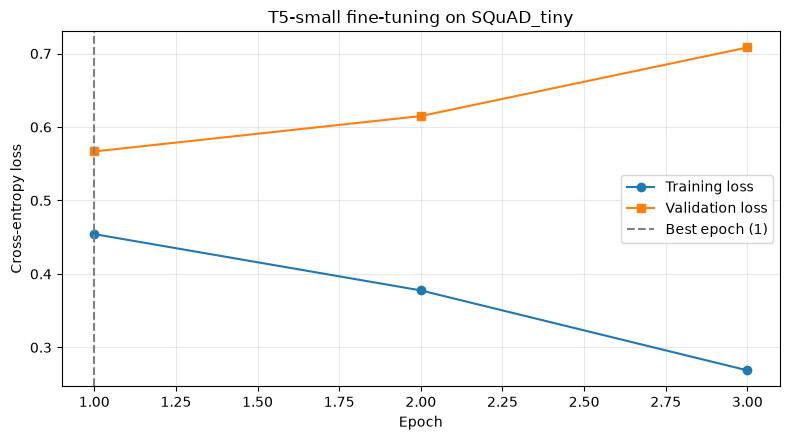

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to saved_models/t5-small-squad_tiny


In [6]:
hist = pd.DataFrame(trainer.state.log_history)
train_loss = hist.dropna(subset=["loss"])[["epoch", "loss"]]
val_loss   = hist.dropna(subset=["eval_loss"])[["epoch", "eval_loss"]]
loss_table = pd.merge(train_loss, val_loss, on="epoch").rename(
    columns={"loss": "training_loss", "eval_loss": "validation_loss"})
loss_table["epoch"] = loss_table["epoch"].round().astype(int)
display(loss_table.round(4))

best_row = loss_table.loc[loss_table["validation_loss"].idxmin()]
print(f"Best validation loss {best_row.validation_loss:.4f} at epoch {int(best_row.epoch)} "
      f"(checkpoint restored: {trainer.state.best_model_checkpoint})")

plt.figure(figsize=(8, 4.5))
plt.plot(loss_table["epoch"], loss_table["training_loss"], "o-", label="Training loss")
plt.plot(loss_table["epoch"], loss_table["validation_loss"], "s-", label="Validation loss")
plt.axvline(best_row.epoch, color="grey", ls="--", label=f"Best epoch ({int(best_row.epoch)})")
plt.xlabel("Epoch"); plt.ylabel("Cross-entropy loss"); plt.title("T5-small fine-tuning on SQuAD_tiny")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150); plt.show()

SAVE_DIR = "saved_models/t5-small-squad_tiny"
trainer.save_model(SAVE_DIR); tokenizer.save_pretrained(SAVE_DIR)
loss_table.to_csv("loss_table.csv", index=False)
print("Best model saved to", SAVE_DIR)

## 2C. Strategies applied to prevent overfitting

1. **Separate validation set** (100 examples from SQuAD *validation*, disjoint from the 1,000 training examples) monitored every epoch — the training/validation gap is the overfitting signal.
2. **Early stopping** (`EarlyStoppingCallback`, patience = 2): training stops once validation loss fails to improve for two consecutive epochs.
3. **Best-checkpoint restoration** (`load_best_model_at_end=True`, `metric_for_best_model="eval_loss"`): the evaluated model is the lowest-validation-loss checkpoint, not the last one.
4. **Weight decay 0.01** (AdamW) — penalises large weights.
5. **Dropout 0.1** in every T5 block (kept active during training).
6. **Transfer learning from a pre-trained checkpoint + small model**: we only adapt `t5-small` rather than training from scratch, and a small model has less capacity to memorise 1,000 examples.
7. **LR warm-up + linear decay**: small updates at the beginning and end of training avoid destroying pre-trained knowledge.
8. The **test set is never used** for any training or model-selection decision.

## 3. Evaluation on the test set (input: question + context)

Answers are generated with beam search (4 beams, max 64 new tokens). **ROUGE-1/2/L F1** (with stemming) are averaged over the 100 test examples. SQuAD's standard **Exact Match** and token **F1** are also shown as supporting metrics.

In [7]:
_scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def generate_answers(mdl, tok, texts, batch_size=16, num_beams=4, max_new_tokens=64):
    mdl.eval(); preds = []
    for i in tqdm(range(0, len(texts), batch_size), desc="generate", leave=False):
        enc = tok(texts[i:i + batch_size], max_length=MAX_INPUT_LENGTH, truncation=True,
                  padding=True, return_tensors="pt").to(device)
        with torch.no_grad():
            out = mdl.generate(**enc, num_beams=num_beams, max_new_tokens=max_new_tokens)
        preds.extend(tok.batch_decode(out, skip_special_tokens=True))
    return [p.strip() for p in preds]

def normalize(s):
    s = s.lower()
    s = "".join(ch for ch in s if ch not in set(string.punctuation))
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    return " ".join(s.split())

def squad_em_f1(pred, gold_list):
    em = max(float(normalize(pred) == normalize(g)) for g in gold_list)
    f1s = []
    for g in gold_list:
        p, t = normalize(pred).split(), normalize(g).split()
        common = sum((Counter(p) & Counter(t)).values())
        if len(p) == 0 or len(t) == 0:
            f1s.append(float(p == t)); continue
        if common == 0:
            f1s.append(0.0); continue
        pr, rc = common / len(p), common / len(t)
        f1s.append(2 * pr * rc / (pr + rc))
    return em, max(f1s)

def rouge_row(pred, gold):
    if not pred.strip():
        return {"rouge1": 0.0, "rouge2": 0.0, "rougeL": 0.0}
    return {k: v.fmeasure for k, v in _scorer.score(gold, pred).items()}

def evaluate(preds, ds):
    golds = [a["text"][0] for a in ds["answers"]]
    rows = [rouge_row(p, g) for p, g in zip(preds, golds)]
    emf1 = [squad_em_f1(p, a["text"]) for p, a in zip(preds, ds["answers"])]
    res = {k: float(np.mean([r[k] for r in rows])) for k in ["rouge1", "rouge2", "rougeL"]}
    res["exact_match"] = float(np.mean([e for e, _ in emf1]))
    res["squad_f1"] = float(np.mean([f for _, f in emf1]))
    res["empty_outputs"] = int(sum(1 for p in preds if not p))
    res["avg_pred_words"] = float(np.mean([len(p.split()) for p in preds]))
    return res, rows

test_ctx_inputs = [encode_question_and_context(q, c) for q, c in zip(test_dataset["question"], test_dataset["context"])]
test_q_inputs   = [encode_question_only(q) for q in test_dataset["question"]]
test_golds      = [a["text"][0] for a in test_dataset["answers"]]

ft_model = trainer.model.to(device)
t0 = time.time()
preds_ft_ctx = generate_answers(ft_model, tokenizer, test_ctx_inputs)
print(f"Generation time for 100 test examples: {time.time()-t0:.1f}s")
ft_ctx_metrics, ft_ctx_rows = evaluate(preds_ft_ctx, test_dataset)

print(f"\nAverage gold answer length: {np.mean([len(g.split()) for g in test_golds]):.2f} words")
display(pd.DataFrame([ft_ctx_metrics], index=["Fine-tuned T5-small (question + context)"]).round(4))

per_example_ft = pd.DataFrame({"question": test_dataset["question"], "gold": test_golds,
                               "prediction": preds_ft_ctx, "rougeL": [r["rougeL"] for r in ft_ctx_rows]})
print("\nDistribution of per-example ROUGE-L:")
print(pd.cut(per_example_ft["rougeL"], [-0.01, 0, 0.5, 0.99, 1.0],
             labels=["0 (wrong)", "(0,0.5]", "(0.5,1)", "1 (exact)"]).value_counts().sort_index())
print("\nLowest-scoring predictions:")
display(per_example_ft.sort_values("rougeL").head(8))

generate:   0%|          | 0/7 [00:00<?, ?it/s]

Generation time for 100 test examples: 4.2s

Average gold answer length: 2.82 words


,rouge1,rouge2,rougeL,exact_match,squad_f1,empty_outputs,avg_pred_words
Fine-tuned T5-small (question + context),0.7328,0.471,0.7328,0.68,0.7722,0,3.43



Distribution of per-example ROUGE-L:
rougeL
0 (wrong)    15
(0,0.5]      11
(0.5,1)      16
1 (exact)    58
Name: count, dtype: int64

Lowest-scoring predictions:


,question,gold,prediction,rougeL
6,By what other name was the Gate known?,Huguon,King Hugo,0.0
14,What is located on the site of The Weaving House currently?,a restaurant,weaving school,0.0
12,What social construct did Huguenot refugees in Canterbury practice?,economic separation,the variety of occupations necessary to sustain the community as distinct from the indigenous population,0.0
21,What was the name of France's primary colony in the New World?,New France,British colonies,0.0
45,What signer of the Articles of Confederation was descended from Huguenots?,Henry Laurens,Paul Revere,0.0
44,What Revolutionary War midnight rider was a Huguenot descendant?,Paul Revere,Jack Jouett,0.0
35,What were the first two destinations of Huguenot emigres?,Switzerland and the Netherlands,"Guanabara Bay, present-day Rio de Janeiro",0.0
33,What were Huguenots who stayed in France eventually known as?,"""new converts""",Catholics,0.0


### 3B. Interpretation of the ROUGE results

| Metric (100 test examples) | Fine-tuned T5-small |
|---|---|
| ROUGE-1 F1 | 0.733 |
| ROUGE-2 F1 | 0.471 |
| ROUGE-L F1 | 0.733 |
| Exact Match / SQuAD F1 | 0.68 / 0.772 |

* **Accuracy.** ROUGE-1 = 0.73 means that, on average, about three-quarters of the answer words are right. The per-example spread shows most of this comes from fully correct answers: 58 are exact (ROUGE-L = 1), 27 are partial, and 15 are completely wrong (ROUGE-L = 0). Exact Match (0.68) agrees with this picture.
* **ROUGE-1 = ROUGE-L.** Gold answers are short (2.8 words on average), and a correct answer is a contiguous span copied from the passage. So the matched words are always in the same order, the longest common subsequence equals the unigram overlap, and the two scores are identical.
* **ROUGE-2 is lower (0.47).** It needs matching *pairs* of words. One-word answers ("1696", "surnames") have no bigrams, so even a correct one-word answer gets ROUGE-2 = 0. Answers that drop a word also lose bigrams ("Edict of Nantes" vs "the revocation of the Edict of Nantes"). The lower score mostly reflects answer length, not poor wording.
* **Fluency.** Outputs are short, well-formed noun phrases, dates and numbers copied from the passage. There are no empty outputs and no repetition. Average length is 3.4 words vs 2.8 for gold, so the model is slightly verbose. The main error types are *boundary* errors (missing determiners or modifiers: "2 million" vs "ca. 2 million") and *wrong-span* errors, where the model picks a plausible entity from the wrong sentence ("Paul Revere" for the signer of the Articles of Confederation). Because the model copies from the passage, fluency is high even when the answer is wrong. ROUGE therefore measures content overlap more than fluency.

## 4. Generative analysis on test samples 0–4
**4A** — input = question + context  **4B** — input = question only (same fine-tuned model, same decoding).

In [8]:
first5 = test_dataset.select(range(5))
q5_ctx = [encode_question_and_context(q, c) for q, c in zip(first5["question"], first5["context"])]
q5_q   = [encode_question_only(q) for q in first5["question"]]

ft5_ctx = generate_answers(ft_model, tokenizer, q5_ctx)
ft5_q   = generate_answers(ft_model, tokenizer, q5_q)

gen_table_ft = pd.DataFrame({
    "idx": range(5),
    "question": first5["question"],
    "gold answer": [a["text"][0] for a in first5["answers"]],
    "4A: question + context": ft5_ctx,
    "ROUGE-L (4A)": [round(rouge_row(p, a["text"][0])["rougeL"], 3) for p, a in zip(ft5_ctx, first5["answers"])],
    "4B: question only": ft5_q,
    "ROUGE-L (4B)": [round(rouge_row(p, a["text"][0])["rougeL"], 3) for p, a in zip(ft5_q, first5["answers"])],
})
display(gen_table_ft)
print("Context passage shared by these samples (first 600 chars):\n", first5[0]["context"][:600], "...")

generate:   0%|          | 0/1 [00:00<?, ?it/s]

generate:   0%|          | 0/1 [00:00<?, ?it/s]

,idx,question,gold answer,4A: question + context,ROUGE-L (4A),4B: question only,ROUGE-L (4B)
0,0,What country initially received the largest number of Huguenot refugees?,the Dutch Republic,the Dutch Republic,1.00,Huguenot,0.000
1,1,How many refugees emigrated to the Dutch Republic?,"an estimated total of 75,000 to 100,000 people","75,000 to 100,000 people",0.75,one,0.000
2,2,What was the population of the Dutch Republic before this emigration?,ca. 2 million,2 million,0.80,Dutch Republic,0.000
3,3,What two areas in the Republic were first to grant rights to the Huguenots?,Amsterdam and the area of West Frisia,Amsterdam and the area of West Frisia,1.00,Huguenots,0.000
4,4,What declaration predicated the emigration of Huguenot refugees?,the revocation of the Edict of Nantes,Edict of Nantes,0.60,emigration of Huguenot refugees?,0.182


Context passage shared by these samples (first 600 chars):
 After the revocation of the Edict of Nantes, the Dutch Republic received the largest group of Huguenot refugees, an estimated total of 75,000 to 100,000 people. Amongst them were 200 clergy. Many came from the region of the Cévennes, for instance, the village of Fraissinet-de-Lozère. This was a huge influx as the entire population of the Dutch Republic amounted to ca. 2 million at that time. Around 1700, it is estimated that nearly 25% of the Amsterdam population was Huguenot.[citation needed] In 1705, Amsterdam and the area of West Frisia were the first areas to provide full citizens rights t ...


In [9]:
# Quantify the effect of context on the whole test set (supports the 4A vs 4B comparison)
preds_ft_q = generate_answers(ft_model, tokenizer, test_q_inputs)
ft_q_metrics, _ = evaluate(preds_ft_q, test_dataset)
context_effect_ft = pd.DataFrame([ft_ctx_metrics, ft_q_metrics],
                                 index=["question + context", "question only"]).round(4)
display(context_effect_ft)

generate:   0%|          | 0/7 [00:00<?, ?it/s]

,rouge1,rouge2,rougeL,exact_match,squad_f1,empty_outputs,avg_pred_words
question + context,0.7328,0.471,0.7328,0.68,0.7722,0,3.43
question only,0.0257,0.000,0.0257,0.00,0.0154,0,2.36


## 5. Comparison with the pre-trained `mrm8488/t5-base-finetuned-squadv2`

**5A.** The model is loaded with `AutoTokenizer` / `AutoModelForSeq2SeqLM`, exactly as in its model card, and fed the same input format `question: ...  context: ...`. A sanity check on sample 0 is printed first to confirm the weights and tokenizer load correctly.

**Loading check (done before this run).** On some numeric questions this checkpoint outputs MathQA-style programs such as `add(const_3,const_4)|...` instead of a text span. A separate diagnostic (`_diag/diag_pretrained.py`, `_diag/tie_test.py`) got identical outputs with the `.safetensors` and `pytorch_model.bin` weights, with `T5Tokenizer` and `AutoTokenizer`, and with `lm_head` forcibly tied to the input embeddings. So this is how the published checkpoint behaves, not a loading error; it is kept and analysed as a limitation in §6.

In [10]:
PRETRAINED_NAME = "mrm8488/t5-base-finetuned-squadv2"
pt_tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_NAME)
pt_model = AutoModelForSeq2SeqLM.from_pretrained(PRETRAINED_NAME).to(device).eval()
print(f"{PRETRAINED_NAME}: {pt_model.num_parameters()/1e6:.1f}M parameters | "
      f"layers enc/dec = {pt_model.config.num_layers}/{pt_model.config.num_decoder_layers} | d_model = {pt_model.config.d_model}")

# sanity check
sanity = generate_answers(pt_model, pt_tokenizer, q5_ctx[:2], num_beams=1)
for i, s in enumerate(sanity):
    print(f"sample {i}: gold = {first5[i]['answers']['text'][0]!r} | pre-trained = {s!r}")

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

mrm8488/t5-base-finetuned-squadv2: 247.6M parameters | layers enc/dec = 12/12 | d_model = 768


generate:   0%|          | 0/1 [00:00<?, ?it/s]

sample 0: gold = 'the Dutch Republic' | pre-trained = 'the Dutch Republic'
sample 1: gold = 'an estimated total of 75,000 to 100,000 people' | pre-trained = 'multiply(n2,const_10)|'


### 5B. Replicating §3 (ROUGE on the test set) and §4 (first 5 samples, with/without context)

In [11]:
preds_pt_ctx = generate_answers(pt_model, pt_tokenizer, test_ctx_inputs)
preds_pt_q   = generate_answers(pt_model, pt_tokenizer, test_q_inputs)
pt_ctx_metrics, pt_ctx_rows = evaluate(preds_pt_ctx, test_dataset)
pt_q_metrics, _ = evaluate(preds_pt_q, test_dataset)
display(pd.DataFrame([pt_ctx_metrics, pt_q_metrics],
                     index=["pre-trained: question + context", "pre-trained: question only"]).round(4))

pt5_ctx = generate_answers(pt_model, pt_tokenizer, q5_ctx)
pt5_q   = generate_answers(pt_model, pt_tokenizer, q5_q)
gen_table_pt = pd.DataFrame({
    "idx": range(5),
    "gold answer": [a["text"][0] for a in first5["answers"]],
    "pre-trained: question + context": pt5_ctx,
    "ROUGE-L (ctx)": [round(rouge_row(p, a["text"][0])["rougeL"], 3) for p, a in zip(pt5_ctx, first5["answers"])],
    "pre-trained: question only": pt5_q,
    "ROUGE-L (q only)": [round(rouge_row(p, a["text"][0])["rougeL"], 3) for p, a in zip(pt5_q, first5["answers"])],
})
display(gen_table_pt)

generate:   0%|          | 0/7 [00:00<?, ?it/s]

generate:   0%|          | 0/7 [00:00<?, ?it/s]

,rouge1,rouge2,rougeL,exact_match,squad_f1,empty_outputs,avg_pred_words
pre-trained: question + context,0.6028,0.4023,0.6028,0.54,0.6314,0,3.19
pre-trained: question only,0.0180,0.0000,0.0180,0.00,0.0118,0,1.77


generate:   0%|          | 0/1 [00:00<?, ?it/s]

generate:   0%|          | 0/1 [00:00<?, ?it/s]

,idx,gold answer,pre-trained: question + context,ROUGE-L (ctx),pre-trained: question only,ROUGE-L (q only)
0,0,the Dutch Republic,the Dutch Republic,1.000,originally received the largest number of Huguenot refugees,0.182
1,1,"an estimated total of 75,000 to 100,000 people","add(const_3,const_4)|multiply(const_10,const_10)|multiply(#0,const_10)|multiply(#1,const_10)|subtract(#2,const_1)|su...",0.000,"multiply(n0,const_100)|",0.143
2,2,ca. 2 million,"divide(n2,const_100)|multiply(n0,n1)|add(#0,const_1)|add(#1,const_1)|add(#2,const_1)|subtract(#0,#2)|subtract(#3,",0.074,"add(const_2,const_3)|add(const_3,const_4)|add(const_3,const_4)|add(#0,#1)|divide(#2,#1)|",0.083
3,3,Amsterdam and the area of West Frisia,Amsterdam and the area of West Frisia,1.000,first to grant rights to the Huguenots,0.143
4,4,the revocation of the Edict of Nantes,Edict of Nantes,0.600,"lcm(n0,n1)|",0.000


### 5C. Side-by-side comparison

,rouge1,rouge2,rougeL,exact_match,squad_f1,empty_outputs,avg_pred_words,parameters (M)
Fine-tuned T5-small (1k SQuAD_tiny),0.7328,0.4710,0.7328,0.68,0.7722,0.0,3.43,60.5
mrm8488/t5-base-finetuned-squadv2,0.6028,0.4023,0.6028,0.54,0.6314,0.0,3.19,247.6


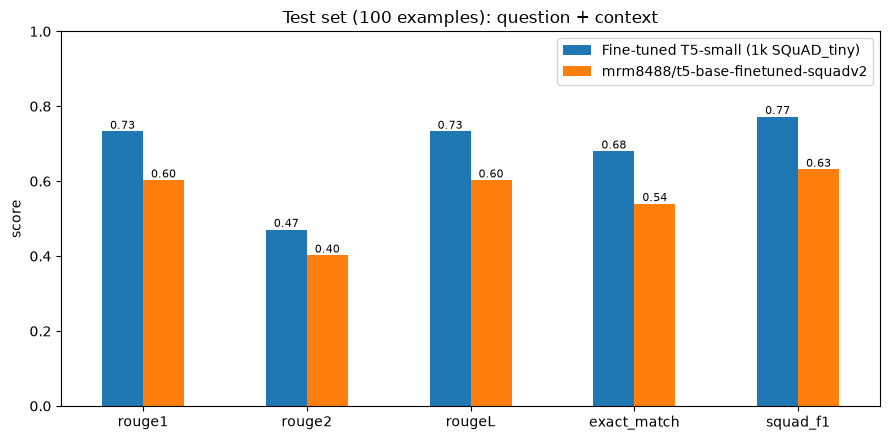

,idx,gold,fine-tuned (ctx),pre-trained (ctx),fine-tuned (q only),pre-trained (q only)
0,0,the Dutch Republic,the Dutch Republic,the Dutch Republic,Huguenot,originally received the largest number of Huguenot refugees
1,1,"an estimated total of 75,000 to 100,000 people","75,000 to 100,000 people","add(const_3,const_4)|multiply(const_10,const_10)|multiply(#0,const_10)|multiply(#1,const_10)|subtract(#2,const_1)|su...",one,"multiply(n0,const_100)|"
2,2,ca. 2 million,2 million,"divide(n2,const_100)|multiply(n0,n1)|add(#0,const_1)|add(#1,const_1)|add(#2,const_1)|subtract(#0,#2)|subtract(#3,",Dutch Republic,"add(const_2,const_3)|add(const_3,const_4)|add(const_3,const_4)|add(#0,#1)|divide(#2,#1)|"
3,3,Amsterdam and the area of West Frisia,Amsterdam and the area of West Frisia,Amsterdam and the area of West Frisia,Huguenots,first to grant rights to the Huguenots
4,4,the revocation of the Edict of Nantes,Edict of Nantes,Edict of Nantes,emigration of Huguenot refugees?,"lcm(n0,n1)|"


Pre-trained better on 18 | fine-tuned better on 38 | tie on 44 examples


,question,gold,fine-tuned,pre-trained,RL fine-tuned,RL pre-trained,delta
21,What was the name of France's primary colony in the New World?,New France,British colonies,New France,0.0,1.0,1.0
19,The French church in Portarlington was built when?,1696,1696,"add(n0,n1)|add(const_1,const_1)|multiply(#0,#1)|",1.0,0.0,-1.0
15,French Church Street is in what Irish town?,Cork City,Cork City,Portarlington,1.0,0.0,-1.0
5,Where was the Gate of King Hugo?,Tours,Tours,Huguon,1.0,0.0,-1.0
35,What were the first two destinations of Huguenot emigres?,Switzerland and the Netherlands,"Guanabara Bay, present-day Rio de Janeiro",Switzerland and the Netherlands,0.0,1.0,1.0
32,How many Huguenots emigrated to North America as colonists?,Four thousand,Four thousand,"add(n0,n1)|subtract(#0,const_1)|",1.0,0.0,-1.0
77,When were these settlers naturalized as English colonists?,12 May 1705,12 May 1705,"add(n1,n2)|subtract(n0,n1)|divide(#1,const_2)|subtract(#0,#2)|",1.0,0.0,-1.0
76,How many settlers original settled in Manakintown?,390,390,"divide(n1,n2)|subtract(n0,n2)|subtract(#0,#1)|",1.0,0.0,-1.0


Saved results_summary.json, loss_curve.png, model_comparison.png


In [12]:
comparison = pd.DataFrame({
    "Fine-tuned T5-small (1k SQuAD_tiny)": ft_ctx_metrics,
    "mrm8488/t5-base-finetuned-squadv2": pt_ctx_metrics,
}).T.round(4)
comparison["parameters (M)"] = [round(ft_model.num_parameters()/1e6, 1), round(pt_model.num_parameters()/1e6, 1)]
display(comparison)

metrics_to_plot = ["rouge1", "rouge2", "rougeL", "exact_match", "squad_f1"]
ax = comparison[metrics_to_plot].T.plot(kind="bar", figsize=(9, 4.5), rot=0)
ax.set_ylim(0, 1); ax.set_ylabel("score"); ax.set_title("Test set (100 examples): question + context")
for c in ax.containers: ax.bar_label(c, fmt="%.2f", fontsize=8)
plt.tight_layout(); plt.savefig("model_comparison.png", dpi=150); plt.show()

side_by_side = pd.DataFrame({
    "idx": range(5), "gold": [a["text"][0] for a in first5["answers"]],
    "fine-tuned (ctx)": ft5_ctx, "pre-trained (ctx)": pt5_ctx,
    "fine-tuned (q only)": ft5_q, "pre-trained (q only)": pt5_q})
display(side_by_side)

# Where do the two models disagree on the full test set?
diff = pd.DataFrame({"question": test_dataset["question"], "gold": test_golds,
                     "fine-tuned": preds_ft_ctx, "pre-trained": preds_pt_ctx,
                     "RL fine-tuned": [r["rougeL"] for r in ft_ctx_rows],
                     "RL pre-trained": [r["rougeL"] for r in pt_ctx_rows]})
diff["delta"] = diff["RL pre-trained"] - diff["RL fine-tuned"]
print("Pre-trained better on", int((diff.delta > 0).sum()), "| fine-tuned better on", int((diff.delta < 0).sum()),
      "| tie on", int((diff.delta == 0).sum()), "examples")
display(diff.reindex(diff.delta.abs().sort_values(ascending=False).index).head(8).round(3))

results = {"fine_tuned": {"ctx": ft_ctx_metrics, "q_only": ft_q_metrics},
           "pretrained": {"ctx": pt_ctx_metrics, "q_only": pt_q_metrics},
           "loss_table": loss_table.to_dict("records")}
json.dump(results, open("results_summary.json", "w"), indent=2)
print("Saved results_summary.json, loss_curve.png, model_comparison.png")

### 5D. Why the results differ: two extra checks

1. **Zero-shot baseline.** The original `t5-small` checkpoint was pre-trained on a multi-task mixture that already included SQuAD with the same `question: … context: …` prefix. Evaluating it *before* fine-tuning shows how much of the score comes from pre-training and how much from our 1,000-example fine-tuning.
2. **Program outputs of the pre-trained model.** Count how many `mrm8488` answers are MathQA-style programs (e.g. `add(n0,n1)|`) and compare both models on the remaining examples.

In [13]:
# (1) zero-shot t5-small (no fine-tuning), same inputs and decoding
zs_model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(device).eval()
preds_zs_ctx = generate_answers(zs_model, tokenizer, test_ctx_inputs)
preds_zs_q   = generate_answers(zs_model, tokenizer, test_q_inputs)
zs_ctx_metrics, zs_ctx_rows = evaluate(preds_zs_ctx, test_dataset)
zs_q_metrics, _ = evaluate(preds_zs_q, test_dataset)
del zs_model; torch.cuda.empty_cache()

all_models = pd.DataFrame([zs_ctx_metrics, ft_ctx_metrics, pt_ctx_metrics, zs_q_metrics, ft_q_metrics, pt_q_metrics],
    index=["t5-small zero-shot | q+ctx", "t5-small fine-tuned | q+ctx", "mrm8488 t5-base | q+ctx",
           "t5-small zero-shot | q only", "t5-small fine-tuned | q only", "mrm8488 t5-base | q only"]).round(4)
display(all_models)

# (2) MathQA-style program outputs from the pre-trained model
is_prog = np.array([bool(re.search(r"\w+\([^)]*\)\|", p)) for p in preds_pt_ctx])
rl_ft = np.array([r["rougeL"] for r in ft_ctx_rows]); rl_pt = np.array([r["rougeL"] for r in pt_ctx_rows])
rl_zs = np.array([r["rougeL"] for r in zs_ctx_rows])
print(f"mrm8488 program-style outputs: {is_prog.sum()} / {len(is_prog)}")
subset = pd.DataFrame({
    "n": [int((~is_prog).sum()), int(is_prog.sum())],
    "ROUGE-L fine-tuned": [rl_ft[~is_prog].mean(), rl_ft[is_prog].mean()],
    "ROUGE-L zero-shot":  [rl_zs[~is_prog].mean(), rl_zs[is_prog].mean()],
    "ROUGE-L mrm8488":    [rl_pt[~is_prog].mean(), rl_pt[is_prog].mean()],
}, index=["normal text answers from mrm8488", "program outputs from mrm8488"]).round(4)
display(subset)
display(pd.DataFrame({"question": test_dataset["question"], "gold": test_golds, "mrm8488": preds_pt_ctx,
                      "fine-tuned": preds_ft_ctx})[is_prog].head(10))

pd.DataFrame({"question": test_dataset["question"], "gold": test_golds,
              "fine_tuned_ctx": preds_ft_ctx, "fine_tuned_q": preds_ft_q,
              "zero_shot_ctx": preds_zs_ctx, "pretrained_ctx": preds_pt_ctx, "pretrained_q": preds_pt_q,
              "pretrained_is_program": is_prog}).to_csv("test_predictions_all_models.csv", index=False)
results["zero_shot"] = {"ctx": zs_ctx_metrics, "q_only": zs_q_metrics}
results["pretrained_program_outputs"] = int(is_prog.sum())
results["subset_rougeL"] = subset.reset_index().to_dict("records")
json.dump(results, open("results_summary.json", "w"), indent=2)
print("Saved test_predictions_all_models.csv and updated results_summary.json")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generate:   0%|          | 0/7 [00:00<?, ?it/s]

generate:   0%|          | 0/7 [00:00<?, ?it/s]

,rouge1,rouge2,rougeL,exact_match,squad_f1,empty_outputs,avg_pred_words
t5-small zero-shot | q+ctx,0.7611,0.5023,0.7611,0.73,0.8056,0,3.37
t5-small fine-tuned | q+ctx,0.7328,0.4710,0.7328,0.68,0.7722,0,3.43
mrm8488 t5-base | q+ctx,0.6028,0.4023,0.6028,0.54,0.6314,0,3.19
t5-small zero-shot | q only,0.0195,0.0000,0.0195,0.00,0.0083,0,2.39
t5-small fine-tuned | q only,0.0257,0.0000,0.0257,0.00,0.0154,0,2.36
mrm8488 t5-base | q only,0.0180,0.0000,0.0180,0.00,0.0118,0,1.77


mrm8488 program-style outputs: 24 / 100


,n,ROUGE-L fine-tuned,ROUGE-L zero-shot,ROUGE-L mrm8488
normal text answers from mrm8488,76,0.7276,0.7726,0.7922
program outputs from mrm8488,24,0.7493,0.7250,0.0031


,question,gold,mrm8488,fine-tuned
1,How many refugees emigrated to the Dutch Republic?,"an estimated total of 75,000 to 100,000 people","add(const_3,const_4)|multiply(const_10,const_10)|multiply(#0,const_10)|multiply(#1,const_10)|subtract(#2,const_1)|su...","75,000 to 100,000 people"
2,What was the population of the Dutch Republic before this emigration?,ca. 2 million,"divide(n2,const_100)|multiply(n0,n1)|add(#0,const_1)|add(#1,const_1)|add(#2,const_1)|subtract(#0,#2)|subtract(#3,",2 million
6,By what other name was the Gate known?,Huguon,"add(n0,const_1)|",King Hugo
12,What social construct did Huguenot refugees in Canterbury practice?,economic separation,"add(const_3,const_4)|add(#0,const_1)|",the variety of occupations necessary to sustain the community as distinct from the indigenous population
19,The French church in Portarlington was built when?,1696,"add(n0,n1)|add(const_1,const_1)|multiply(#0,#1)|",1696
32,How many Huguenots emigrated to North America as colonists?,Four thousand,"add(n0,n1)|subtract(#0,const_1)|",Four thousand
36,When was the French colony in modern day Brazil founded?,1555,"factorial(n0)|factorial(n1)|subtract(n0,n1)|factorial(#2)|subtract(#0,#2)|",1555
37,What was the Brazilian French colony called?,France Antarctique,"add(n0,n1)|subtract(#0,const_1)|",France Antarctique
40,Families with French names in South Africa speak what language today?,Afrikaans,"add(n0,n1)|add(n2,#0)|add(n3,#1)|",Afrikaans-speaking
42,Where can one find the formerly Huguenot farms in South Africa?,Western Cape province,"add(const_3,const_4)|add(#0,const_10)|",Western Cape province


Saved test_predictions_all_models.csv and updated results_summary.json


## 6. Discussion

**Training.** Validation loss was lowest after epoch 1 (0.567) and rose in epochs 2–3 (0.615, 0.708), while training loss kept falling (0.454 → 0.269). This is classic overfitting on 1,000 examples. Early stopping ended training at epoch 3 and restored the epoch-1 checkpoint, which is the model evaluated above.

**Context vs. no context (§4).** With context, the model answers samples 0 and 3 exactly and samples 1, 2 and 4 with only boundary differences. With the question only, every answer is wrong ("Huguenot", "one", "Dutch Republic"). Over the full test set, ROUGE-L falls from 0.733 to 0.026 and Exact Match from 0.68 to 0. SQuAD answers are facts about a specific passage, and a 60 M-parameter model stores very little world knowledge. Without the passage it can only echo words from the question or guess a type-appropriate filler ("one" for "how many"). The system reads the passage to answer; it does not work as a closed-book QA model.

**Pre-trained `mrm8488/t5-base-finetuned-squadv2` (§5).** On the same inputs it scores lower overall (ROUGE-L 0.603, EM 0.54) despite being 4× larger and trained on all of SQuAD v2. The reason is **24/100 outputs that are MathQA-style programs** (`add(n0,n1)|subtract(#0,const_1)|`) instead of text. The loading diagnostic rules out a tokenizer or weights problem, so this is how the published checkpoint behaves. It looks like contamination from arithmetic-QA data, and it is triggered mainly by questions with numbers or dates. On the other 76 examples, the pre-trained model is clearly better (ROUGE-L 0.792 vs 0.728 for our model), as its size and much larger training set would suggest. With question only, it also fails (0.018), confirming the context effect.

**Zero-shot baseline (§5D).** Without any fine-tuning, `t5-small` already reaches ROUGE-L 0.761 / EM 0.73, slightly *higher* than our fine-tuned model (0.733 / 0.68). This happens because the public T5 checkpoints were pre-trained on a multi-task mixture that already included SQuAD with the same `question: … context:` prompt. Fine-tuning on 1,000 examples at LR 3e-4 therefore adds little and slightly overfits. The difference is 5 exact matches out of 100, which is within the noise of such a small test set. A lower learning rate, freezing the encoder, or a larger training set would be the next things to try, selecting on validation loss (not test ROUGE) to avoid leakage.

**Limitations.** The test set has only 100 questions from a few Wikipedia articles (mostly Huguenots), so differences of a few points are not statistically reliable. ROUGE and EM also penalise correct answers phrased differently from the single gold span. In addition, bf16 training on GPU is not bit-for-bit deterministic, so re-running can change scores by about ±1 point.